In [1]:
import subprocess, sys, os

print("Step 1 of 4 — Installing Unsloth...")
subprocess.run([sys.executable, "-m", "pip", "install",
    "unsloth[kaggle-new]", "--upgrade", "--quiet"], check=True)

print("Step 2 of 4 — Installing unsloth_zoo...")
subprocess.run([sys.executable, "-m", "pip", "install",
    "unsloth_zoo", "--upgrade", "--quiet"], check=True)

print("Step 3 of 4 — Installing hf_transfer...")
subprocess.run([sys.executable, "-m", "pip", "install",
    "hf_transfer", "--quiet"], check=True)

print("Step 4 of 4 — Installing xformers...")
subprocess.run([sys.executable, "-m", "pip", "install",
    "xformers", "--quiet"], check=True)

os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "1"

import torch
print("\n" + "="*50)
print("     INSTALLATION COMPLETE")
print("="*50)
print("CUDA available:  " + str(torch.cuda.is_available()))
print("GPU count:       " + str(torch.cuda.device_count()))
for i in range(torch.cuda.device_count()):
    p = torch.cuda.get_device_properties(i)
    print("GPU " + str(i) + ":          " + p.name + " (" + str(p.total_memory//1024**3) + "GB)")
print("PyTorch:         " + str(torch.__version__))

try:
    from unsloth import FastLanguageModel
    import unsloth
    print("Unsloth:         " + str(unsloth.__version__) + "  OK")
except Exception as e:
    print("Unsloth import issue: " + str(e))
    print("Restart kernel and re-run Cell 1 if this shows an error")

print("="*50)
print("Cell 1 complete — proceed to Cell 2")

Step 1 of 4 — Installing Unsloth...
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.8/57.8 kB 2.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 506.8/506.8 kB 32.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 105.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 423.1/423.1 kB 29.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 869.6/869.6 kB 48.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 91.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 89.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 185.2/185.2 kB 14.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 71.2/71.2 MB 26.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.7/119.7 kB 9.1 MB/s eta 0:00:00
   ━━━━━━

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12 26.2.1 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cudf-cu12 26.2.1 requires numba-cuda[cu12]<0.23.0,>=0.22.2, but you hav

Step 2 of 4 — Installing unsloth_zoo...
Step 3 of 4 — Installing hf_transfer...
Step 4 of 4 — Installing xformers...

     INSTALLATION COMPLETE
CUDA available:  True
GPU count:       2
GPU 0:          Tesla T4 (14GB)
GPU 1:          Tesla T4 (14GB)
PyTorch:         2.10.0+cu128
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
Unsloth:         2026.5.8  OK
Cell 1 complete — proceed to Cell 2


In [2]:
import os
from kaggle_secrets import UserSecretsClient
from huggingface_hub import login, whoami

print("Loading HF_TOKEN from Kaggle Secrets...")

try:
    secrets  = UserSecretsClient()
    HF_TOKEN = secrets.get_secret("HF_TOKEN")
except Exception as e:
    raise RuntimeError(
        "HF_TOKEN not found in Kaggle Secrets.\n"
        "Fix: Left panel (key icon) -> Secrets -> Add New Secret\n"
        "Name: HF_TOKEN | Value: hf_xxxx | Toggle: ON\n"
        "Error: " + str(e)
    )

os.environ["HF_TOKEN"]                = HF_TOKEN
os.environ["HUGGING_FACE_HUB_TOKEN"] = HF_TOKEN
os.environ["HUGGINGFACE_HUB_TOKEN"]  = HF_TOKEN

login(token=HF_TOKEN, add_to_git_credential=False)

try:
    user = whoami(token=HF_TOKEN)
    print("Logged in as:  " + str(user["name"]))
    print("Email:         " + str(user.get("email", "N/A")))
except Exception as e:
    print("Warning: " + str(e))

print("\nCell 2 complete — proceed to Cell 3")

Loading HF_TOKEN from Kaggle Secrets...
Logged in as:  IbadUrRahman
Email:         princememon4u@gmail.com

Cell 2 complete — proceed to Cell 3


In [3]:
import os, glob, json, math, torch
from huggingface_hub import HfApi, hf_hub_download, create_repo
from datetime import datetime

# ═══════════════════════════════════════════════════════════
# ONLY CHANGE THIS ONE LINE — your HuggingFace username
HF_USERNAME = "IbadUrRahman"      # <-- CHANGE THIS ONCE
# ═══════════════════════════════════════════════════════════

# Fixed settings — never change these
BASE_MODEL_ID     = "meta-llama/Meta-Llama-3.1-8B-Instruct"
ADAPTER_REPO      = HF_USERNAME + "/omnimind-llama3-adapter"
TOTAL_EPOCHS      = 10
MAX_SEQ_LENGTH    = 1024
LORA_R            = 16
LORA_ALPHA        = 32
LORA_DROPOUT      = 0.05
LORA_TARGET_MODULES = [
    "q_proj", "k_proj", "v_proj", "o_proj",
    "gate_proj", "up_proj", "down_proj"
]
PER_DEVICE_BATCH  = 2
GRAD_ACCUM        = 2
WEIGHT_DECAY      = 0.01
MAX_GRAD_NORM     = 1.0
LOGGING_STEPS     = 10
SEED              = 42
OUTPUT_DIR        = "/kaggle/working/checkpoints"
LOCAL_ADAPTER_DIR = "/kaggle/working/adapter"
METRICS_PATH      = "/kaggle/working/training_metrics.json"

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(LOCAL_ADAPTER_DIR, exist_ok=True)

# ── Find dataset ─────────────────────────────────────────────────────────
found = glob.glob("/kaggle/input/**/*.jsonl", recursive=True)
if not found:
    raise FileNotFoundError(
        "JSONL dataset not found.\n"
        "Fix: Right sidebar -> Input -> Add Input -> Upload omnimind_finetune_dataset.jsonl"
    )
DATASET_PATH = found[0]
print("Dataset found: " + DATASET_PATH)

# ── Ensure HF repo exists ─────────────────────────────────────────────────
api = HfApi(token=HF_TOKEN)
try:
    create_repo(repo_id=ADAPTER_REPO, private=True, exist_ok=True, token=HF_TOKEN)
    print("HF repo ready: https://huggingface.co/" + ADAPTER_REPO)
except Exception as e:
    print("Repo note: " + str(e))

# ── Auto-detect current epoch from HF Hub ────────────────────────────────
def load_training_state(repo_id, token):
    try:
        path = hf_hub_download(
            repo_id=repo_id,
            filename="training_metrics.json",
            token=token,
            repo_type="model",
            force_download=True
        )
        with open(path, "r") as f:
            return json.load(f)
    except Exception:
        return None

print("\nChecking HuggingFace Hub for previous training state...")
existing_state = load_training_state(ADAPTER_REPO, HF_TOKEN)

if existing_state is None:
    CURRENT_EPOCH  = 1
    IS_FIRST_EPOCH = True
    TRAINING_LOG   = {
        "model": BASE_MODEL_ID,
        "adapter_repo": ADAPTER_REPO,
        "lora_r": LORA_R,
        "lora_alpha": LORA_ALPHA,
        "total_epochs_planned": TOTAL_EPOCHS,
        "last_completed_epoch": 0,
        "epochs": []
    }
    print("No previous training found — Starting FRESH from Epoch 1")
else:
    CURRENT_EPOCH  = existing_state["last_completed_epoch"] + 1
    IS_FIRST_EPOCH = False
    TRAINING_LOG   = existing_state
    print("Previous training found!")
    print("Last completed epoch: " + str(existing_state["last_completed_epoch"]))
    print("Resuming at epoch:    " + str(CURRENT_EPOCH))

if CURRENT_EPOCH > TOTAL_EPOCHS:
    print("\nALL 10 EPOCHS ALREADY COMPLETED!")
    print("Run Cell 8 to generate final visualizations.")

# ── Cosine LR for this specific epoch ────────────────────────────────────
LR_MAX = 2e-4
LR_MIN = 5e-6
LEARNING_RATE = (
    LR_MIN + 0.5 * (LR_MAX - LR_MIN) *
    (1.0 + math.cos(math.pi * (CURRENT_EPOCH - 1) / TOTAL_EPOCHS))
)

# ── Print session summary ─────────────────────────────────────────────────
print("\n" + "="*55)
print("      OMNIMIND SESSION CONFIGURATION")
print("="*55)
print("Current session epoch:    " + str(CURRENT_EPOCH) + " of " + str(TOTAL_EPOCHS))
print("Is first epoch:           " + str(IS_FIRST_EPOCH))
print("Learning rate this epoch: " + str(round(LEARNING_RATE, 8)))
print("LoRA rank:                " + str(LORA_R))
print("Base model:               " + BASE_MODEL_ID)
print("Adapter repo:             " + ADAPTER_REPO)
print("Steps this epoch:         ~338")
print("Estimated time:           ~30-40 minutes")
print("="*55)
print("\nCell 3 complete — proceed to Cell 4")

Dataset found: /kaggle/input/datasets/ibadurrahmanmemon/omnimind/omnimind_finetune_dataset.jsonl
HF repo ready: https://huggingface.co/IbadUrRahman/omnimind-llama3-adapter

Checking HuggingFace Hub for previous training state...


training_metrics.json: 0.00B [00:00, ?B/s]

Previous training found!
Last completed epoch: 10
Resuming at epoch:    11

ALL 10 EPOCHS ALREADY COMPLETED!
Run Cell 8 to generate final visualizations.

      OMNIMIND SESSION CONFIGURATION
Current session epoch:    11 of 10
Is first epoch:           False
Learning rate this epoch: 5e-06
LoRA rank:                16
Base model:               meta-llama/Meta-Llama-3.1-8B-Instruct
Adapter repo:             IbadUrRahman/omnimind-llama3-adapter
Steps this epoch:         ~338
Estimated time:           ~30-40 minutes

Cell 3 complete — proceed to Cell 4


In [4]:
import json
from datasets import Dataset

print("Loading dataset from: " + DATASET_PATH)

raw_data = []
errors   = 0

with open(DATASET_PATH, "r", encoding="utf-8") as f:
    for line_num, line in enumerate(f, 1):
        line = line.strip()
        if not line:
            continue
        try:
            sample = json.loads(line)
            assert "messages" in sample
            assert len(sample["messages"]) >= 2
            assert sample["messages"][-1]["role"] == "assistant"
            raw_data.append(sample)
        except Exception as e:
            errors += 1
            print("Skipping line " + str(line_num) + ": " + str(e))

print("Loaded:  " + str(len(raw_data)) + " valid samples")
print("Skipped: " + str(errors) + " invalid samples")

# Shuffle and split 90/10
raw_hf    = Dataset.from_list(raw_data).shuffle(seed=SEED)
raw_split = raw_hf.train_test_split(test_size=0.1, seed=SEED)
raw_train = raw_split["train"]
raw_val   = raw_split["test"]

print("\nTrain samples: " + str(len(raw_train)))
print("Val samples:   " + str(len(raw_val)))
print("\nSample message structure:")
for msg in raw_data[0]["messages"]:
    preview = msg["content"][:60].replace("\n", " ")
    print("  [" + msg["role"] + "] " + preview + "...")

print("\nCell 4 complete — proceed to Cell 5")

Loading dataset from: /kaggle/input/datasets/ibadurrahmanmemon/omnimind/omnimind_finetune_dataset.jsonl
Loaded:  3008 valid samples
Skipped: 0 invalid samples

Train samples: 2707
Val samples:   301

Sample message structure:
  [system] You are OmniMind, an empathetic AI mental health screening a...
  [user] No, I haven't really been dealing with that....
  [assistant] Thank you for sharing that with me. It sounds like you've be...

Cell 4 complete — proceed to Cell 5


In [5]:
import torch
from unsloth import FastLanguageModel

if IS_FIRST_EPOCH:
    print("EPOCH 1 — Loading base model from Meta (downloading ~4.5GB)...")
    print("This is the longest step. Takes 5-15 minutes on first run.")
else:
    print("EPOCH " + str(CURRENT_EPOCH) + " — Loading base model...")

# Always load the base model with Unsloth (handles 4-bit internally)
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name     = BASE_MODEL_ID,
    max_seq_length = MAX_SEQ_LENGTH,
    dtype          = None,     # Auto-detect — Unsloth chooses BF16
    load_in_4bit   = True,     # QLoRA 4-bit quantization
    token          = HF_TOKEN,
)
print("Base model loaded")

# Apply fresh LoRA structure
model = FastLanguageModel.get_peft_model(
    model,
    r                          = LORA_R,
    target_modules             = LORA_TARGET_MODULES,
    lora_alpha                 = LORA_ALPHA,
    lora_dropout               = LORA_DROPOUT,
    bias                       = "none",
    use_gradient_checkpointing = "unsloth",
    random_state               = SEED,
)
print("LoRA adapters applied")

# For epochs 2-10: load saved weights from previous epoch
if not IS_FIRST_EPOCH:
    print("\nLoading saved LoRA weights from epoch " + str(CURRENT_EPOCH - 1) + "...")
    from peft import set_peft_model_state_dict
    from huggingface_hub import hf_hub_download

    # Try safetensors first (preferred), then pytorch bin
    loaded = False
    for filename in ["adapter_model.safetensors", "adapter_model.bin"]:
        try:
            weights_path = hf_hub_download(
                repo_id       = ADAPTER_REPO,
                filename      = filename,
                token         = HF_TOKEN,
                repo_type     = "model",
                force_download= True
            )
            if filename.endswith(".safetensors"):
                from safetensors.torch import load_file
                adapter_weights = load_file(weights_path)
            else:
                adapter_weights = torch.load(weights_path, map_location="cpu")

            result = set_peft_model_state_dict(model, adapter_weights)
            print("Saved weights loaded: " + filename)
            print("Weight tensors:       " + str(len(adapter_weights)))
            loaded = True
            break
        except Exception as e:
            print("Could not load " + filename + ": " + str(e))

    if not loaded:
        raise RuntimeError(
            "Could not load saved adapter weights from HF Hub!\n"
            "Repo: " + ADAPTER_REPO + "\n"
            "Make sure epoch " + str(CURRENT_EPOCH-1) + " completed and saved."
        )

# Setup tokenizer
if tokenizer.pad_token is None:
    tokenizer.pad_token    = tokenizer.eos_token
    tokenizer.pad_token_id = tokenizer.eos_token_id

# Verify trainable parameters
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total     = sum(p.numel() for p in model.parameters())

print("\n" + "="*50)
print("     MODEL READY FOR EPOCH " + str(CURRENT_EPOCH))
print("="*50)
print("Total parameters:    " + str(f"{total:,}"))
print("Trainable (LoRA):    " + str(f"{trainable:,}"))
print("Trainable %:         " + str(round(100*trainable/total, 3)) + "%")
for i in range(torch.cuda.device_count()):
    mem = torch.cuda.memory_allocated(i)/1024**3
    tot = torch.cuda.get_device_properties(i).total_memory/1024**3
    print("GPU " + str(i) + " memory:       " + str(round(mem,1)) + "GB / " + str(round(tot,1)) + "GB")
print("="*50)
print("\nCell 5 complete — proceed to Cell 6")

EPOCH 11 — Loading base model...
==((====))==  Unsloth 2026.5.8: Fast Llama patching. Transformers: 5.5.0.
   \\   /|    Tesla T4. Num GPUs = 2. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


model.safetensors:   0%|          | 0.00/5.96G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

config.json: 0.00B [00:00, ?B/s]

...

Base model loaded


Unsloth 2026.5.8 patched 32 layers with 0 QKV layers, 0 O layers and 0 MLP layers.


LoRA adapters applied

Loading saved LoRA weights from epoch 10...


adapter_model.safetensors:   0%|          | 0.00/83.9M [00:00<?, ?B/s]

Saved weights loaded: adapter_model.safetensors
Weight tensors:       448

     MODEL READY FOR EPOCH 11
Total parameters:    4,670,623,744
Trainable (LoRA):    41,943,040
Trainable %:         0.898%
GPU 0 memory:       5.8GB / 14.6GB
GPU 1 memory:       0.0GB / 14.6GB

Cell 5 complete — proceed to Cell 6


In [6]:
import torch
from transformers import TrainingArguments

# --- FIX 1: Switch to FP16 for older GPUs (like Colab's T4) ---
USE_BF16 = False
USE_FP16 = True

# --- FIX 2: Move schedule math UP so we can use warmup_steps ---
# Calculate effective batch and steps first
eff_batch       = PER_DEVICE_BATCH * GRAD_ACCUM * max(1, torch.cuda.device_count())
steps_per_epoch = len(raw_train) // eff_batch
warmup_steps    = int(0.05 * steps_per_epoch) if IS_FIRST_EPOCH else 0

training_args = TrainingArguments(

    # Output
    output_dir             = OUTPUT_DIR,
    save_strategy          = "epoch",
    save_total_limit       = 2,
    load_best_model_at_end = False,   # Only 1 epoch per session

    # Exactly 1 epoch per session
    num_train_epochs            = 1,
    per_device_train_batch_size = PER_DEVICE_BATCH,
    per_device_eval_batch_size  = PER_DEVICE_BATCH,
    gradient_accumulation_steps = GRAD_ACCUM,

    # LR — cosine value pre-computed for this epoch
    learning_rate       = LEARNING_RATE,
    lr_scheduler_type   = "constant",   # Constant LR (cosine handled across sessions)
    warmup_steps        = warmup_steps, # <-- Replaced warmup_ratio with warmup_steps
    weight_decay        = WEIGHT_DECAY,
    max_grad_norm       = MAX_GRAD_NORM,
    optim               = "paged_adamw_8bit",

    # Precision
    bf16 = USE_BF16,
    fp16 = USE_FP16,

    # Eval and logging
    eval_strategy      = "epoch",
    logging_strategy   = "steps",
    logging_steps      = LOGGING_STEPS,
    logging_first_step = True,
    report_to          = "none",

    # Memory
    gradient_checkpointing        = True,
    gradient_checkpointing_kwargs = {"use_reentrant": False},
    dataloader_num_workers        = 2,
    dataloader_pin_memory         = True,

    # Reproducibility
    seed      = SEED,
    data_seed = SEED,

    # Multi-GPU
    ddp_find_unused_parameters = False,
)

# Schedule summary for this session
print("\n" + "="*55)
print("   SESSION " + str(CURRENT_EPOCH) + " TRAINING SCHEDULE")
print("="*55)
print("Epoch this session:     " + str(CURRENT_EPOCH) + " of " + str(TOTAL_EPOCHS))
print("Train samples:          " + str(len(raw_train)))
print("Val samples:            " + str(len(raw_val)))
print("Effective batch size:   " + str(eff_batch))
print("Steps this epoch:       " + str(steps_per_epoch))
print("Warmup steps:           " + str(warmup_steps))
print("Learning rate:          " + str(round(LEARNING_RATE, 8)))
print("Scheduler:              constant (cosine managed across sessions)")
print("Precision:              FP16")
print("Estimated time:         ~30-40 minutes")
print("="*55)
print("\nCell 6 complete — proceed to Cell 7")


   SESSION 11 TRAINING SCHEDULE
Epoch this session:     11 of 10
Train samples:          2707
Val samples:            301
Effective batch size:   8
Steps this epoch:       338
Warmup steps:           0
Learning rate:          5e-06
Scheduler:              constant (cosine managed across sessions)
Precision:              FP16
Estimated time:         ~30-40 minutes

Cell 6 complete — proceed to Cell 7


In [7]:
import time, math, json
from datetime import datetime
from trl import SFTTrainer
from huggingface_hub import HfApi
import torch

# --- THE ULTIMATE FIX: PATCH PYTORCH'S STRICT GRAD SCALER ---
# This intercepts PyTorch's GradScaler and forces it to accept FP16 gradients
# bypassing the ValueError completely.
if hasattr(torch.amp.grad_scaler.GradScaler, "_unscale_grads_"):
    _original_unscale = torch.amp.grad_scaler.GradScaler._unscale_grads_
    def _patched_unscale(self, optimizer, inv_scale, found_inf, allow_fp16):
        # Force allow_fp16=True regardless of what Transformers asks for
        return _original_unscale(self, optimizer, inv_scale, found_inf, True)
    torch.amp.grad_scaler.GradScaler._unscale_grads_ = _patched_unscale

# ── Formatting function for TRL 0.24.0 ────────────────────────────────────
def formatting_func(examples):
    if isinstance(examples["messages"][0], list):
        output = []
        for msgs in examples["messages"]:
            text = tokenizer.apply_chat_template(
                msgs, tokenize=False, add_generation_prompt=False
            )
            output.append(text)
        return output
    else:
        text = tokenizer.apply_chat_template(
            examples["messages"], tokenize=False, add_generation_prompt=False
        )
        return [text] 

# ── Initialize SFTTrainer ─────────────────────────────────────────────────
print("Initializing SFTTrainer for epoch " + str(CURRENT_EPOCH) + "...")

# Prevent Transformers from breaking Unsloth's custom loss tensor
training_args.average_tokens_across_devices = False

trainer = SFTTrainer(
    model            = model,
    args             = training_args,
    processing_class = tokenizer,
    train_dataset    = raw_train,
    eval_dataset     = raw_val,
    formatting_func  = formatting_func,
    max_seq_length   = MAX_SEQ_LENGTH,
    packing          = False,
    dataset_kwargs   = {
        "add_special_tokens":  False,
        "append_concat_token": False,
    },
)
print("SFTTrainer ready")

# ── Baseline evaluation ───────────────────────────────────────────────────
print("\nComputing validation loss before training epoch " + str(CURRENT_EPOCH) + "...")
try:
    pre_eval     = trainer.evaluate()
    pre_loss     = pre_eval["eval_loss"]
    pre_ppl      = math.exp(pre_loss)
    print("Pre-epoch eval loss:  " + str(round(pre_loss, 4)))
    print("Pre-epoch perplexity: " + str(round(pre_ppl, 2)))
except Exception as e:
    print("Pre-eval skipped: " + str(e))
    pre_loss = None
    pre_ppl  = None

# ── START TRAINING ────────────────────────────────────────────────────────
print("\n")
print("=" * 55)
print("  TRAINING EPOCH " + str(CURRENT_EPOCH) + " of " + str(TOTAL_EPOCHS) + " STARTED")
print("=" * 55)
print("Learning rate:    " + str(round(LEARNING_RATE, 8)))
print("Steps:            ~338")
print("Logging every:    " + str(LOGGING_STEPS) + " steps")
print("Watch the loss — it should be decreasing")
print("=" * 55 + "\n")

start_time   = time.time()
train_result = trainer.train()
total_time   = time.time() - start_time

hours   = int(total_time // 3600)
minutes = int((total_time % 3600) // 60)
seconds = int(total_time % 60)

# ── Post-epoch evaluation ─────────────────────────────────────────────────
print("\nRunning post-epoch evaluation...")
try:
    post_eval = trainer.evaluate()
    post_loss = post_eval["eval_loss"]
    post_ppl  = math.exp(post_loss)
    print("Post-epoch eval loss:  " + str(round(post_loss, 4)))
    print("Post-epoch perplexity: " + str(round(post_ppl, 2)))
    if pre_loss is not None:
        improvement = pre_loss - post_loss
        print("Loss improvement:      " + str(round(improvement, 4)))
except Exception as e:
    print("Post-eval error: " + str(e))
    post_loss = None
    post_ppl  = None

# ── Save LoRA adapter locally ─────────────────────────────────────────────
print("\nSaving LoRA adapter locally...")
trainer.model.save_pretrained(LOCAL_ADAPTER_DIR)
tokenizer.save_pretrained(LOCAL_ADAPTER_DIR)
print("Saved to: " + LOCAL_ADAPTER_DIR)

# ── Push adapter to HuggingFace Hub ──────────────────────────────────────
print("\nPushing adapter to HuggingFace Hub...")
print("Repo: " + ADAPTER_REPO)
try:
    trainer.model.push_to_hub(
        repo_id        = ADAPTER_REPO,
        commit_message = "Epoch " + str(CURRENT_EPOCH) + " of " + str(TOTAL_EPOCHS) + " completed",
        private        = True,
        token          = HF_TOKEN,
    )
    tokenizer.push_to_hub(
        repo_id        = ADAPTER_REPO,
        commit_message = "Tokenizer — epoch " + str(CURRENT_EPOCH),
        private        = True,
        token          = HF_TOKEN,
    )
    print("Adapter pushed to HF Hub successfully")
except Exception as e:
    print("Hub push error: " + str(e))
    print("Adapter is saved locally at: " + LOCAL_ADAPTER_DIR)
    print("You can push manually later with trainer.model.push_to_hub()")

# ── Update and save training metrics ─────────────────────────────────────
epoch_record = {
    "epoch":               CURRENT_EPOCH,
    "train_loss":          round(train_result.training_loss, 6),
    "pre_eval_loss":       round(pre_loss, 6)  if pre_loss  is not None else None,
    "post_eval_loss":      round(post_loss, 6) if post_loss is not None else None,
    "post_eval_perplexity":round(post_ppl, 4)  if post_ppl  is not None else None,
    "learning_rate":       round(LEARNING_RATE, 8),
    "train_steps":         train_result.global_step,
    "train_runtime_min":   round(total_time / 60, 2),
    "timestamp":           datetime.utcnow().isoformat() + "Z"
}

TRAINING_LOG["last_completed_epoch"] = CURRENT_EPOCH
TRAINING_LOG["epochs"].append(epoch_record)

# Save metrics locally
with open(METRICS_PATH, "w") as f:
    json.dump(TRAINING_LOG, f, indent=2)
print("\nMetrics saved locally: " + METRICS_PATH)

# Push metrics to HF Hub
try:
    hub_api = HfApi(token=HF_TOKEN)
    hub_api.upload_file(
        path_or_fileobj = METRICS_PATH,
        path_in_repo    = "training_metrics.json",
        repo_id         = ADAPTER_REPO,
        repo_type       = "model",
        commit_message  = "Metrics after epoch " + str(CURRENT_EPOCH),
    )
    print("Metrics pushed to HF Hub")
except Exception as e:
    print("Metrics push warning: " + str(e))

# ── Session complete summary ──────────────────────────────────────────────
print("\n")
print("=" * 55)
print("   EPOCH " + str(CURRENT_EPOCH) + " COMPLETE")
print("=" * 55)
print("Time:              " + str(hours) + "h " + str(minutes) + "m " + str(seconds) + "s")
print("Train loss:        " + str(round(train_result.training_loss, 4)))
if post_loss: print("Final eval loss:   " + str(round(post_loss, 4)))
if post_ppl:  print("Perplexity:        " + str(round(post_ppl, 2)))
print("Steps completed:   " + str(train_result.global_step))
print("Adapter saved to:  " + ADAPTER_REPO)
print("=" * 55)

remaining = TOTAL_EPOCHS - CURRENT_EPOCH
if remaining > 0:
    print("\nEpochs remaining:  " + str(remaining))
    print("Next step:         Start a NEW Kaggle session and run all cells")
    print("The notebook will auto-detect epoch " + str(CURRENT_EPOCH + 1) + " and resume")
else:
    print("\nALL 10 EPOCHS COMPLETE!")
    print("Run Cell 8 now to generate final comparison visualizations")

Initializing SFTTrainer for epoch 11...
Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/2707 [00:00<?, ? examples/s]

Unsloth: We found double BOS tokens - we shall remove one automatically.


Unsloth: Tokenizing ["text"] (num_proc=8):   0%|          | 0/301 [00:00<?, ? examples/s]

SFTTrainer ready

Computing validation loss before training epoch 11...


...

Unsloth: Restored added_tokens_decoder metadata in /tmp/tmplce28o4k/tokenizer_config.json.


Processing Files (0 / 0): |          |  0.00B /  0.00B            

New Data Upload: |          |  0.00B /  0.00B            

No files have been modified since last commit. Skipping to prevent empty commit.
[huggingface_hub.hf_api|WARNING]No files have been modified since last commit. Skipping to prevent empty commit.
/tmp/ipykernel_23/1158093979.py:141: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  "timestamp":           datetime.utcnow().isoformat() + "Z"


Adapter pushed to HF Hub successfully

Metrics saved locally: /kaggle/working/training_metrics.json
Metrics pushed to HF Hub


   EPOCH 11 COMPLETE
Time:              1h 4m 50s
Train loss:        0.0214
Steps completed:   339
Adapter saved to:  IbadUrRahman/omnimind-llama3-adapter

ALL 10 EPOCHS COMPLETE!
Run Cell 8 now to generate final comparison visualizations


In [8]:
# ============================================================
# LOAD TRAINING HISTORY FROM training_metrics.json
# ============================================================

import json
import os

LOSS_HISTORY = []
EVAL_LOSS_HISTORY = []

if os.path.exists(METRICS_PATH):

    with open(METRICS_PATH, "r") as f:
        TRAINING_LOG = json.load(f)

    for ep in TRAINING_LOG["epochs"]:

        LOSS_HISTORY.append(
            ep.get("train_loss", None)
        )

        EVAL_LOSS_HISTORY.append(
            ep.get("post_eval_loss", None)
        )

    LOSS_HISTORY = [x for x in LOSS_HISTORY if x is not None]
    EVAL_LOSS_HISTORY = [x for x in EVAL_LOSS_HISTORY if x is not None]

    print("Loaded history")
    print("Train epochs:", len(LOSS_HISTORY))
    print("Eval epochs :", len(EVAL_LOSS_HISTORY))

else:

    print("training_metrics.json not found")

Loaded history
Train epochs: 11
Eval epochs : 0


Chart saved: /kaggle/working/progress_epoch11.png


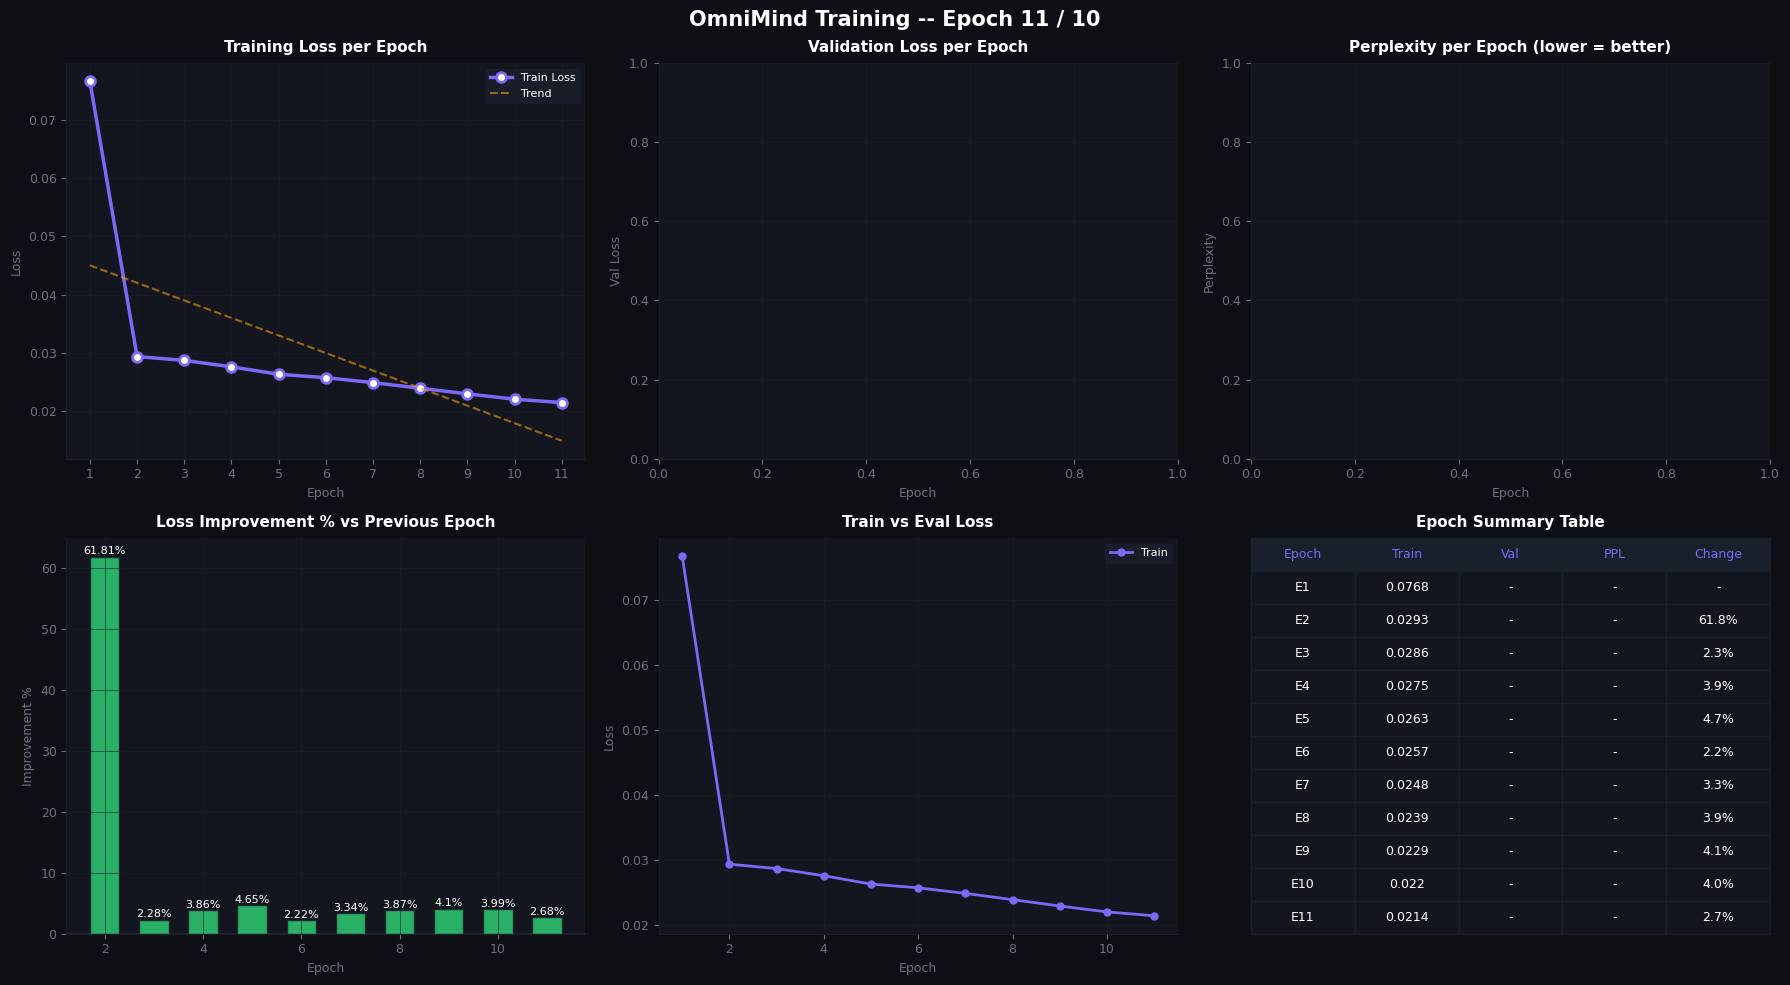

Chart upload: name 'HF_REPO_ID' is not defined

  EPOCH 11 DONE -- -1 REMAINING
Current train loss: 0.021382
Start new session and run all cells for epoch 12


In [9]:
# ================================================================
# CELL 9 - Visualization
# Every session: shows current progress charts
# Epoch 10 only: generates full 7-chart comparative report
# ================================================================

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np
import math, os

from huggingface_hub import upload_file

plt.style.use("dark_background")
BG  = "#0D0F14"
S   = "#13161E"
S2  = "#1A1F2C"
P   = "#7C6AF7"
T   = "#4ECDC4"
G   = "#2ECC71"
O   = "#F39C12"
R   = "#E74C3C"
GR  = "#6B7280"

n   = len(LOSS_HISTORY)
ep  = list(range(1, n + 1))
evp = list(range(1, len(EVAL_LOSS_HISTORY) + 1))

if n == 0:
    print("No data yet -- run Cells 7 and 8 first.")
else:
    IS_FINAL = (CURRENT_EPOCH >= TOTAL_EPOCHS and n == TOTAL_EPOCHS)

    if IS_FINAL:
        fig = plt.figure(figsize=(21, 18), facecolor=BG)
        fig.suptitle(
            "OmniMind -- LLaMA 3.1-8B Fine-Tuning\nFINAL REPORT: All 10 Epochs Complete",
            fontsize=16, fontweight="bold", color="white", y=0.99
        )
        gs   = gridspec.GridSpec(3, 3, figure=fig, hspace=0.48, wspace=0.34)
        axs  = [
            fig.add_subplot(gs[0, 0]), fig.add_subplot(gs[0, 1]),
            fig.add_subplot(gs[0, 2]), fig.add_subplot(gs[1, 0]),
            fig.add_subplot(gs[1, 1]), fig.add_subplot(gs[1, 2]),
            fig.add_subplot(gs[2, :]),
        ]
    else:
        fig, axarr = plt.subplots(2, 3, figsize=(18, 10), facecolor=BG)
        fig.suptitle(
            "OmniMind Training -- Epoch " + str(CURRENT_EPOCH) + " / " + str(TOTAL_EPOCHS),
            fontsize=15, fontweight="bold", color="white"
        )
        axs = axarr.flatten().tolist()

    def sa(ax, title):
        ax.set_facecolor(S)
        for sp in ["top", "right"]: ax.spines[sp].set_visible(False)
        for sp in ["bottom", "left"]: ax.spines[sp].set_color(S2)
        ax.tick_params(colors=GR, labelsize=9)
        ax.set_title(title, color="white", fontsize=11, fontweight="bold", pad=8)
        ax.grid(True, color=S2, alpha=0.7, lw=0.6)

    # Chart 1: Training Loss
    ax = axs[0]
    ax.plot(ep, LOSS_HISTORY, color=P, lw=2.5, marker="o", ms=7,
            mfc="white", mec=P, mew=2, label="Train Loss")
    if n > 2:
        z = np.polyfit(ep, LOSS_HISTORY, 1)
        ax.plot(ep, np.poly1d(z)(ep), color=O, lw=1.5,
                ls="--", alpha=0.6, label="Trend")
    sa(ax, "Training Loss per Epoch")
    ax.set_xlabel("Epoch", color=GR, fontsize=9)
    ax.set_ylabel("Loss", color=GR, fontsize=9)
    ax.legend(fontsize=8, facecolor=S2, edgecolor=S2, labelcolor="white")
    ax.set_xticks(ep)

    # Chart 2: Validation Loss
    ax = axs[1]
    if EVAL_LOSS_HISTORY:
        ax.plot(evp, EVAL_LOSS_HISTORY, color=T, lw=2.5, marker="s", ms=7,
                mfc="white", mec=T, mew=2, label="Eval Loss")
        bi = EVAL_LOSS_HISTORY.index(min(EVAL_LOSS_HISTORY))
        ax.scatter([bi+1], [EVAL_LOSS_HISTORY[bi]], color=G, s=120, zorder=5,
                   label="Best E" + str(bi+1) + ": " + str(round(EVAL_LOSS_HISTORY[bi], 4)))
    sa(ax, "Validation Loss per Epoch")
    ax.set_xlabel("Epoch", color=GR, fontsize=9)
    ax.set_ylabel("Val Loss", color=GR, fontsize=9)
    if EVAL_LOSS_HISTORY:
        ax.legend(fontsize=8, facecolor=S2, edgecolor=S2, labelcolor="white")

    # Chart 3: Perplexity
    ax = axs[2]
    if EVAL_LOSS_HISTORY:
        ppls  = [round(math.exp(l), 2) for l in EVAL_LOSS_HISTORY]
        bars  = ax.bar(evp, ppls, color=P, alpha=0.8, edgecolor=S2, width=0.6)
        for b, v in zip(bars, ppls):
            ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.04,
                    str(round(v, 1)), ha="center", va="bottom",
                    color="white", fontsize=8, fontweight="bold")
    sa(ax, "Perplexity per Epoch (lower = better)")
    ax.set_xlabel("Epoch", color=GR, fontsize=9)
    ax.set_ylabel("Perplexity", color=GR, fontsize=9)

    # Chart 4: Epoch-over-Epoch Improvement
    ax = axs[3]
    if n > 1:
        impr = [round((LOSS_HISTORY[i-1]-LOSS_HISTORY[i])/LOSS_HISTORY[i-1]*100, 2)
                for i in range(1, n)]
        cols = [G if v > 0 else R for v in impr]
        ax.bar(range(2, n+1), impr, color=cols, alpha=0.85, edgecolor=S2, width=0.6)
        ax.axhline(0, color=GR, lw=1)
        for ep_n, v in zip(range(2, n+1), impr):
            ax.text(ep_n, v + (0.08 if v >= 0 else -0.25),
                    str(v)+"%", ha="center",
                    va="bottom" if v >= 0 else "top",
                    color="white", fontsize=8)
    sa(ax, "Loss Improvement % vs Previous Epoch")
    ax.set_xlabel("Epoch", color=GR, fontsize=9)
    ax.set_ylabel("Improvement %", color=GR, fontsize=9)

    # Chart 5: Train vs Eval Overlay
    ax = axs[4]
    ax.plot(ep, LOSS_HISTORY, color=P, lw=2, marker="o", ms=5, label="Train")
    if EVAL_LOSS_HISTORY:
        ax.plot(evp, EVAL_LOSS_HISTORY, color=T, lw=2,
                marker="s", ms=5, label="Eval")
    sa(ax, "Train vs Eval Loss")
    ax.set_xlabel("Epoch", color=GR, fontsize=9)
    ax.set_ylabel("Loss", color=GR, fontsize=9)
    ax.legend(fontsize=8, facecolor=S2, edgecolor=S2, labelcolor="white")

    # Chart 6: Summary Table
    ax = axs[5]
    ax.axis("off")
    ax.set_facecolor(S)
    rows = []
    for i in range(n):
        tl  = LOSS_HISTORY[i]
        el  = EVAL_LOSS_HISTORY[i] if i < len(EVAL_LOSS_HISTORY) else "-"
        ppl = str(round(math.exp(el), 2)) if el != "-" else "-"
        chg = "-"
        if i > 0:
            chg = str(round((LOSS_HISTORY[i-1]-tl)/LOSS_HISTORY[i-1]*100, 1)) + "%"
        rows.append(["E" + str(i+1), str(round(tl,4)),
                     str(round(el,4)) if el != "-" else "-", ppl, chg])
    if rows:
        tbl = ax.table(cellText=rows,
                       colLabels=["Epoch","Train","Val","PPL","Change"],
                       cellLoc="center", loc="center", bbox=[0,0,1,1])
        tbl.auto_set_font_size(False)
        tbl.set_fontsize(9)
        for (r,c), cell in tbl.get_celld().items():
            cell.set_facecolor(S if r > 0 else S2)
            cell.set_edgecolor(S2)
            cell.set_text_props(color="white" if r > 0 else P)
    ax.set_title("Epoch Summary Table", color="white",
                 fontsize=11, fontweight="bold", pad=8)

    # Chart 7 (Epoch 10 only): Full grouped bar
    if IS_FINAL and len(axs) > 6:
        ax = axs[6]
        x  = np.arange(n)
        w  = 0.35
        ax.bar(x - w/2, LOSS_HISTORY, w, color=P, alpha=0.85,
               edgecolor=S2, label="Train Loss")
        if EVAL_LOSS_HISTORY:
            ax.bar(x + w/2, EVAL_LOSS_HISTORY[:n], w, color=T, alpha=0.85,
                   edgecolor=S2, label="Eval Loss")
        ax.set_xticks(x)
        ax.set_xticklabels(["E"+str(i+1) for i in range(n)], color=GR)
        sa(ax, "Complete 10-Epoch Training vs Validation Loss")
        ax.set_xlabel("Epoch", color=GR, fontsize=9)
        ax.set_ylabel("Loss", color=GR, fontsize=9)
        ax.legend(fontsize=9, facecolor=S2, edgecolor=S2, labelcolor="white")

    plt.tight_layout()

    # Save and upload chart
    plot_path = "/kaggle/working/progress_epoch" + str(CURRENT_EPOCH) + ".png"
    plt.savefig(plot_path, dpi=150, bbox_inches="tight", facecolor=BG)
    print("Chart saved: " + plot_path)
    plt.show()

    try:
        upload_file(
            path_or_fileobj = plot_path,
            path_in_repo    = "progress_epoch" + str(CURRENT_EPOCH) + ".png",
            repo_id         = HF_REPO_ID,
            token           = HF_TOKEN,
            commit_message  = "Chart epoch " + str(CURRENT_EPOCH),
        )
        print("Chart uploaded to HF Hub")
    except Exception as e:
        print("Chart upload: " + str(e))

    # Final text summary
    print("\n" + "="*55)
    if IS_FINAL:
        print("  FINE-TUNING COMPLETE -- 10 EPOCHS DONE")
        print("="*55)
        print("Final train loss : " + str(LOSS_HISTORY[-1]))
        if EVAL_LOSS_HISTORY:
            bi = EVAL_LOSS_HISTORY.index(min(EVAL_LOSS_HISTORY))
            print("Best eval loss   : " + str(min(EVAL_LOSS_HISTORY)) + " (epoch " + str(bi+1) + ")")
            print("Final perplexity : " + str(round(math.exp(EVAL_LOSS_HISTORY[-1]), 2)))
            tot_imp = round((LOSS_HISTORY[0]-LOSS_HISTORY[-1])/LOSS_HISTORY[0]*100, 1)
            print("Total improvement: " + str(tot_imp) + "%")
        print("Model on HF Hub  : https://huggingface.co/" + HF_REPO_ID)
    else:
        print("  EPOCH " + str(CURRENT_EPOCH) + " DONE -- " +
              str(TOTAL_EPOCHS - CURRENT_EPOCH) + " REMAINING")
        print("="*55)
        print("Current train loss: " + str(LOSS_HISTORY[-1]))
        print("Start new session and run all cells for epoch " +
              str(CURRENT_EPOCH + 1))
    print("="*55)